# Interacting with Geoparquet files.

This notebook is an example of how we can load a geoparquet file. Run spatio-temporal queries on it and carry out mathematical and numerical operations.

Given a parquet file (usually stored on AWS S3) we can read and interact with it using the `geopandas` and `stac_geoparquet` package. 

We can then convert the data to stac items and lad it into an ODC xarray dataset for further operations.

### Load the required libraries

In [1]:
import stac_geoparquet
import geopandas as gpd
from odc.stac import load, configure_s3_access
import shapely

### Setup the environment

AWS profile is needed if you are using different profile than the `default` profile. AWS access id, secret key and aws access token if required should be configured via the credential file or AWS SSO.

In [2]:
# Put your AWS profile name here. If you have AWS credentials set up in your environment, you can set this to None.
aws_profile = "dev2"

# Set your storage options for reading/writing from/to S3. If you have AWS credentials set up in your environment, you can leave this as an empty dictionary.
# You can also set this to a dictionary with AWS credentials, e.g. {"aws_access_key_id": "xxx", "aws_secret_access_key": "yyy"}.
# If you have AWS credentials set up in your environment, you can leave this as an empty dictionary.
storage_options = {"profile": aws_profile} if aws_profile else {}

if aws_profile:
    configure_s3_access(aws_profile)

### Example geoparquet file hosted on AWS S3

In [3]:
parquet_file_s3_url = "s3://dea-public-data-dev/experimental/ga_s1_nrb.parquet"

### Loading the geoparquet file directly into a geopandas dataframe.

In [4]:
gdf = gpd.read_parquet(parquet_file_s3_url, storage_options=storage_options)

### Querying by bounding box

In [5]:
bbox = [-178, -79, 0, -76]
bbox = shapely.geometry.box(*bbox)
filtered_bbox = gdf[gdf.intersects(bbox)]
filtered_bbox.head()

,assets,collection,geometry,id,links,stac_extensions,stac_version,type,ceosard:specification,ceosard:specification_version,...,sarard:static_tropospheric_correction_applied,sarard:wet_tropospheric_correction_applied,sarard:zero_doppler_end_time,sarard:zero_doppler_start_time,sat:absolute_orbit,sat:orbit_cycle,sat:orbit_state,sat:relative_orbit,start_datetime,storage:schemes
0,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-176.99427 -77.8734, -177.00998 -77....",ga_s1a_nrb_0-1-0_T055-117593-IW2_20150525T120553Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:56.480573Z,2015-05-25T12:05:53.382850Z,6077,12,descending,55,2015-05-25 12:05:54.399025+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
1,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.51927 -77.09482, -177.53209 -77...",ga_s1a_nrb_0-1-0_T055-117593-IW3_20150525T120554Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:57.444623Z,2015-05-25T12:05:54.346900Z,6077,12,descending,55,2015-05-25 12:05:55.477062+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
2,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.27164 -78.63054, -177.28756 -78...",ga_s1a_nrb_0-1-0_T055-117594-IW1_20150525T120555Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:58.283288Z,2015-05-25T12:05:55.197898Z,6077,12,descending,55,2015-05-25 12:05:56.325099+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
3,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.79753 -77.88477, -177.81039 -77...",ga_s1a_nrb_0-1-0_T055-117594-IW2_20150525T120556Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:59.241178Z,2015-05-25T12:05:56.143455Z,6077,12,descending,55,2015-05-25 12:05:57.157302+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."


### Querying by time

In [6]:
filtered_time = gdf[
    (gdf.datetime >= "2015-05-25 12:05:53") & (gdf.datetime <= "2015-05-25 12:06:00")
]
filtered_time.head()

,assets,collection,geometry,id,links,stac_extensions,stac_version,type,ceosard:specification,ceosard:specification_version,...,sarard:static_tropospheric_correction_applied,sarard:wet_tropospheric_correction_applied,sarard:zero_doppler_end_time,sarard:zero_doppler_start_time,sat:absolute_orbit,sat:orbit_cycle,sat:orbit_state,sat:relative_orbit,start_datetime,storage:schemes
0,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-176.99427 -77.8734, -177.00998 -77....",ga_s1a_nrb_0-1-0_T055-117593-IW2_20150525T120553Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:56.480573Z,2015-05-25T12:05:53.382850Z,6077,12,descending,55,2015-05-25 12:05:54.399025+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
1,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.51927 -77.09482, -177.53209 -77...",ga_s1a_nrb_0-1-0_T055-117593-IW3_20150525T120554Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:57.444623Z,2015-05-25T12:05:54.346900Z,6077,12,descending,55,2015-05-25 12:05:55.477062+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
2,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.27164 -78.63054, -177.28756 -78...",ga_s1a_nrb_0-1-0_T055-117594-IW1_20150525T120555Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:58.283288Z,2015-05-25T12:05:55.197898Z,6077,12,descending,55,2015-05-25 12:05:56.325099+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
3,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-177.79753 -77.88477, -177.81039 -77...",ga_s1a_nrb_0-1-0_T055-117594-IW2_20150525T120556Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:05:59.241178Z,2015-05-25T12:05:56.143455Z,6077,12,descending,55,2015-05-25 12:05:57.157302+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."
4,{'checksum': {'description': 'product folder c...,ga_s1_nrb_iw_hh_1,"POLYGON ((-178.27467 -77.10475, -178.285 -77.0...",ga_s1a_nrb_0-1-0_T055-117594-IW3_20150525T120557Z,[{'href': 's3://dea-public-data-dev/experiment...,[https://stac-extensions.github.io/classificat...,1.1.0,Feature,NRB,5.5,...,True,False,2015-05-25T12:06:00.203183Z,2015-05-25T12:05:57.105460Z,6077,12,descending,55,2015-05-25 12:05:58.235339+00:00,"{'aws': {'bucket': 'dea-public-data-dev', 'pla..."


In [ ]:
# filtered_gdf.explore()

### Converting the geopandas dataframe to stac Items

In [7]:
stac_collection = stac_geoparquet.to_item_collection(filtered_bbox)

### Loading the items into an ODC dataset 

In [8]:
ds = load(
    stac_collection,
    chunks={},
    resolution=50,
    crs="EPSG:3031",
)
ds

<xarray.Dataset> Size: 597MB
Dimensions:                    (y: 5146, x: 1036, time: 4)
Coordinates:
  * y                          (y) float64 41kB -1.232e+06 ... -1.489e+06
  * x                          (x) float64 8kB -7.432e+04 ... -2.258e+04
  * time                       (time) datetime64[ns] 32B 2015-05-25T12:05:53....
    spatial_ref                int32 4B 3031
Data variables:
    hh_gamma0                  (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_gamma0_to_beta0_ratio   (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_gamma0_to_sigma0_ratio  (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_incidence_angle         (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_layover_shadow_mask     (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_local_incidence_angle   (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>
    oa_number_of_looks         (time, y, x) float32 85MB dask.array<chunksize=(1, 5146, 1036), meta=np.ndarray>

### Plotting the dataset's `hh_gamma0` band.

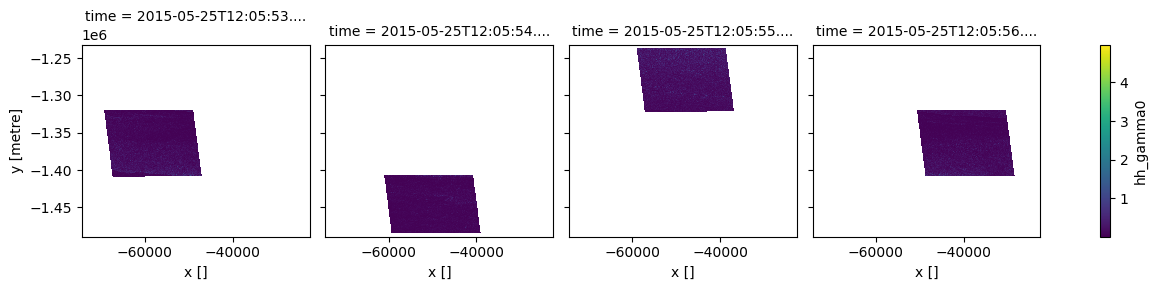

In [9]:
ds.hh_gamma0.plot.imshow(col="time")